# Clustering Algorithms

This module provides an in-depth study of clustering techniques including K-Means, Hierarchical Clustering, and DBSCAN.

## Learning Objectives

- Understand different clustering algorithms
- Evaluate clustering quality
- Compare clustering methods

**What is Clustering?**
Clustering groups similar data points together without knowing the groups beforehand. It's like organizing a messy room - you group similar items together.

**Key Clustering Algorithms:**
1. **K-Means**: Divides data into k clusters (need to specify k)
2. **Hierarchical**: Creates tree of clusters (dendrogram)
3. **DBSCAN**: Finds clusters of arbitrary shape (density-based)

**Evaluation Metrics:**
- **Silhouette Score**: Measures how well-separated clusters are (-1 to 1, higher is better)
- **Inertia**: Sum of squared distances to cluster centers (lower is better, but can overfit)


Wine Dataset: 178 samples, 13 features

K-Means Silhouette Score: 0.571
Hierarchical Silhouette Score: 0.564
DBSCAN Silhouette Score: 0.202

DBSCAN found 6 clusters and 45 noise points


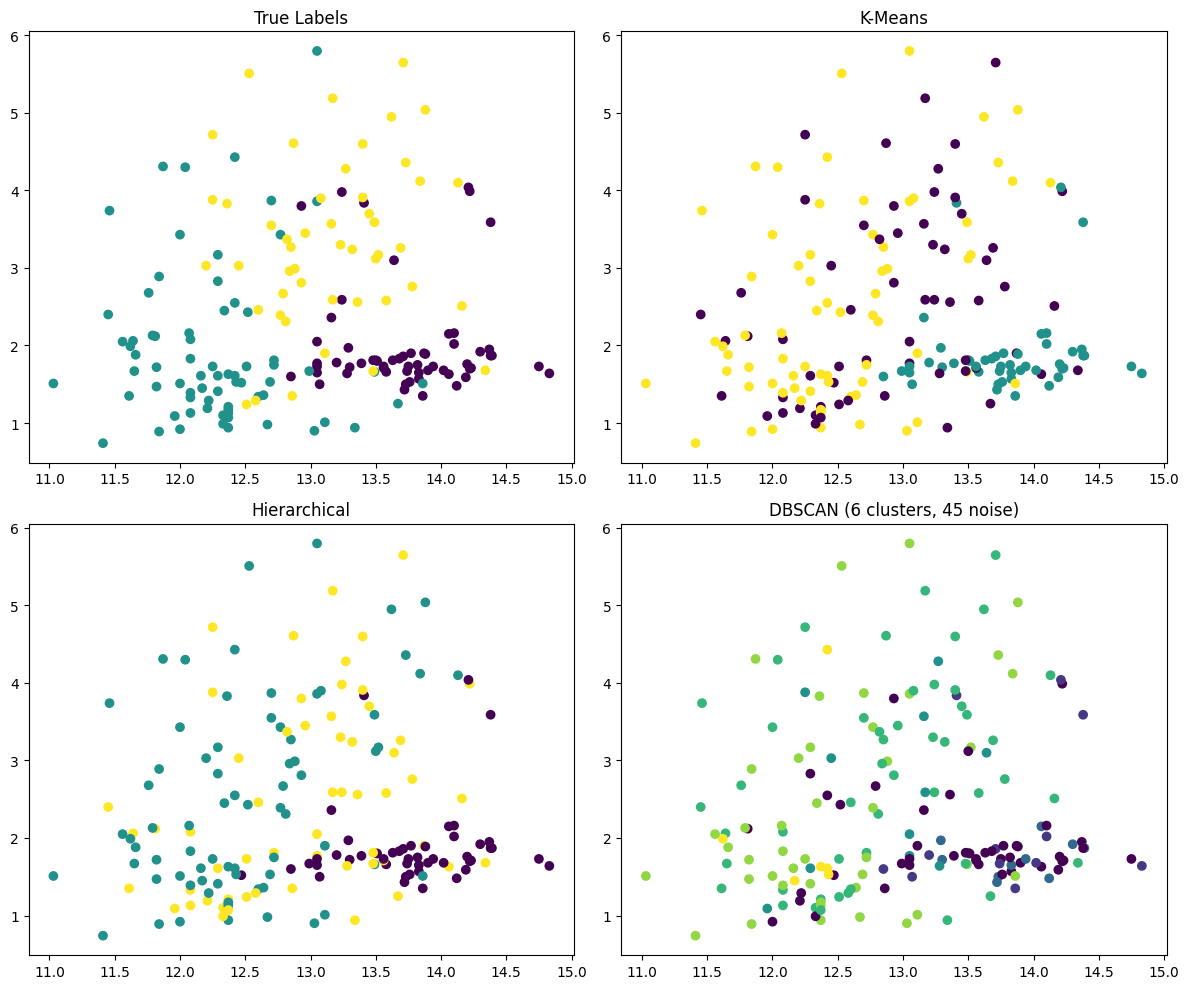

In [ ]:
# ============================================
# IMPORTING LIBRARIES: Clustering Tools
# ============================================

# Scikit-learn: Machine learning library
from sklearn.datasets import load_wine  # Wine classification dataset

# Our custom utility functions
from src.models.unsupervised import (
    kmeans_cluster,  # K-Means clustering
    hierarchical_cluster,  # Hierarchical clustering
    dbscan_cluster,  # DBSCAN clustering
    evaluate_clustering  # Evaluate clustering quality (silhouette score)
)

# Visualization and data manipulation
import matplotlib.pyplot as plt  # Plotting library
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computing

# ============================================
# LOADING THE DATASET: Wine Classification
# ============================================

# load_wine() loads the Wine dataset from scikit-learn
# This dataset has 3 wine classes (we'll ignore labels for clustering)
wine = load_wine()  # Returns a Bunch object
X = pd.DataFrame(wine.data, columns=wine.feature_names)  # Features: wine chemical measurements
y = wine.target  # True labels (for comparison only - not used in clustering)

print(f"Wine Dataset: {X.shape[0]} samples, {X.shape[1]} features")  # 178 wines, 13 features

# ============================================
# CLUSTERING ALGORITHM 1: K-Means
# ============================================

# K-Means divides data into k clusters
# n_clusters=3: We want 3 clusters (we know there are 3 wine types)
# random_state=42: Ensures reproducible results
kmeans_labels, kmeans_model = kmeans_cluster(X.values, n_clusters=3, random_state=42)
# Returns:
# - kmeans_labels: Cluster assignments (0, 1, or 2 for each sample)
# - kmeans_model: The fitted K-Means model

# ============================================
# CLUSTERING ALGORITHM 2: Hierarchical Clustering
# ============================================

# Hierarchical clustering creates a tree of clusters
# n_clusters=3: Cut tree to get 3 clusters
hierarchical_labels, hier_model = hierarchical_cluster(X.values, n_clusters=3)
# Returns:
# - hierarchical_labels: Cluster assignments
# - hier_model: The fitted hierarchical clustering model

# ============================================
# CLUSTERING ALGORITHM 3: DBSCAN
# ============================================

# DBSCAN finds clusters of arbitrary shape based on density
# eps=20: Maximum distance between points in same cluster
# min_samples=5: Minimum points to form a cluster
# DBSCAN can find noise points (outliers) labeled as -1
dbscan_labels, dbscan_model = dbscan_cluster(X.values, eps=20, min_samples=5)
# Returns:
# - dbscan_labels: Cluster assignments (-1 = noise/outlier)
# - dbscan_model: The fitted DBSCAN model

# ============================================
# EVALUATING CLUSTERING QUALITY: Silhouette Score
# ============================================

# Silhouette score measures how well-separated clusters are
# Range: -1 (poor) to +1 (excellent)
# Higher is better

# Evaluate K-Means
kmeans_score = evaluate_clustering(X.values, kmeans_labels)
print(f"\nK-Means Silhouette Score: {kmeans_score:.3f}")

# Evaluate Hierarchical
hierarchical_score = evaluate_clustering(X.values, hierarchical_labels)
print(f"Hierarchical Silhouette Score: {hierarchical_score:.3f}")

# Evaluate DBSCAN (may have issues if too few clusters)
dbscan_score = evaluate_clustering(X.values, dbscan_labels)

# Count clusters and noise points for DBSCAN
# np.unique() gets unique cluster labels
# dbscan_labels != -1 filters out noise points
# len() counts how many clusters were found
n_clusters_dbscan = len(np.unique(dbscan_labels[dbscan_labels != -1]))

# Count noise points (labeled as -1)
# np.sum() counts how many labels equal -1
n_noise = np.sum(dbscan_labels == -1)

# Display DBSCAN results
if dbscan_score >= 0:
    print(f"DBSCAN Silhouette Score: {dbscan_score:.3f}")
else:
    # If score is negative or invalid, clustering may have failed
    print(f"DBSCAN: Insufficient clusters for silhouette score (found {n_clusters_dbscan} clusters, {n_noise} noise points)")
    print("Note: DBSCAN found too few clusters. Try adjusting eps parameter.")

print(f"\nDBSCAN found {n_clusters_dbscan} clusters and {n_noise} noise points")

# ============================================
# VISUALIZATION: Comparing All Clustering Methods
# ============================================

# Create 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns

# Plot 1: True labels (ground truth for comparison)
axes[0, 0].scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='viridis')
axes[0, 0].set_title('True Labels')  # What we know from supervised learning

# Plot 2: K-Means clusters
axes[0, 1].scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans_labels, cmap='viridis')
axes[0, 1].set_title('K-Means')  # K-Means discovered clusters

# Plot 3: Hierarchical clusters
axes[1, 0].scatter(X.iloc[:, 0], X.iloc[:, 1], c=hierarchical_labels, cmap='viridis')
axes[1, 0].set_title('Hierarchical')  # Hierarchical discovered clusters

# Plot 4: DBSCAN clusters
axes[1, 1].scatter(X.iloc[:, 0], X.iloc[:, 1], c=dbscan_labels, cmap='viridis')
axes[1, 1].set_title(f'DBSCAN ({n_clusters_dbscan} clusters, {n_noise} noise)')  # DBSCAN results

# Adjust layout
plt.tight_layout()
plt.show()  # Display all plots

# Interpretation:
# - Compare discovered clusters (bottom 3 plots) with true labels (top left)
# - If clusters match true labels well, algorithm found the right groups
# - Different algorithms may find different patterns
# - DBSCAN can identify noise points (outliers) that don't belong to any cluster
